<a href="https://colab.research.google.com/github/Shreya5619/System-Threat-Forecaster/blob/main/system_threat_forecaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import pandas as pd

# Step 1: Unzip the file
with zipfile.ZipFile('System-Threat-Forecaster.zip', 'r') as zip_ref:
    zip_ref.extractall('System-Threat-Forecaster')

# Step 2: Load the CSV into a DataFrame
df = pd.read_csv('System-Threat-Forecaster/train.csv')

# Step 3: View the data (optional)
print(df.head())


                          MachineID   ProductName EngineVersion  \
0  f541bae429089117c4aac39c90dd3416  win8defender   1.1.15200.1   
1  dc2b14d9ce3a0ce4050bb640190f2ca5  win8defender   1.1.15100.1   
2  fd20c5f010e9c5f91ad1c6b3e0da68a0  win8defender   1.1.15200.1   
3  38711eae85eb77a72ec5dfdf27eb2a76  win8defender   1.1.15200.1   
4  32607c9a543a9214e2c7e45800ed4849  win8defender   1.1.15200.1   

         AppVersion SignatureVersion  IsBetaUser  RealTimeProtectionState  \
0   4.18.1807.18075     1.275.1003.0           0                      7.0   
1   4.18.1807.18075     1.273.1465.0           0                      7.0   
2   4.18.1807.18075     1.275.1546.0           0                      7.0   
3  4.12.17007.18011     1.275.1141.0           0                      7.0   
4    4.13.17134.228     1.275.1283.0           0                      7.0   

   IsPassiveModeEnabled  AntivirusConfigID  NumAntivirusProductsInstalled  \
0                     0            53447.0               

In [ ]:
df=pd.DataFrame(df)
df.dropna()
X = df.drop(columns=['target'])  # Features
y = df['target']  # Target variable

## 🧪 Exploratory Data Analysis (EDA)

We begin by exploring the structure and composition of the dataset to understand its dimensions, data types, and missing values.

The dataset consists of **100,000 rows and 76 columns**, including a mix of numerical, categorical, and boolean features. The `target` column is our binary label for system threat prediction.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  HasTpm                     

### 🔍 Key Observations:
- 31 columns are floats, 17 are integers, and 28 are categorical (`object`).
- Most columns are complete, but a few (e.g., `CityID`, `SMode`, `IsGamer`) have missing values.
- Many features represent system/hardware configurations (e.g., `Processor`, `RAM`, `OSVersion`) or security settings (e.g., `FirewallEnabled`, `IsSecureBootEnabled`).
- Several high-cardinality features (like `MachineID`, `CityID`, `OSBuildLab`) may need special handling.


## 📈 Histogram of Numerical Features

To understand the distribution of numerical features, we plot histograms. This helps identify skewness, outliers, and common value ranges in the data.

Visualizing these distributions provides insight into how features like RAM, processor count, and protection states are spread across the dataset. It also helps in deciding whether transformations (e.g., normalization or log-scaling) are needed before model training.


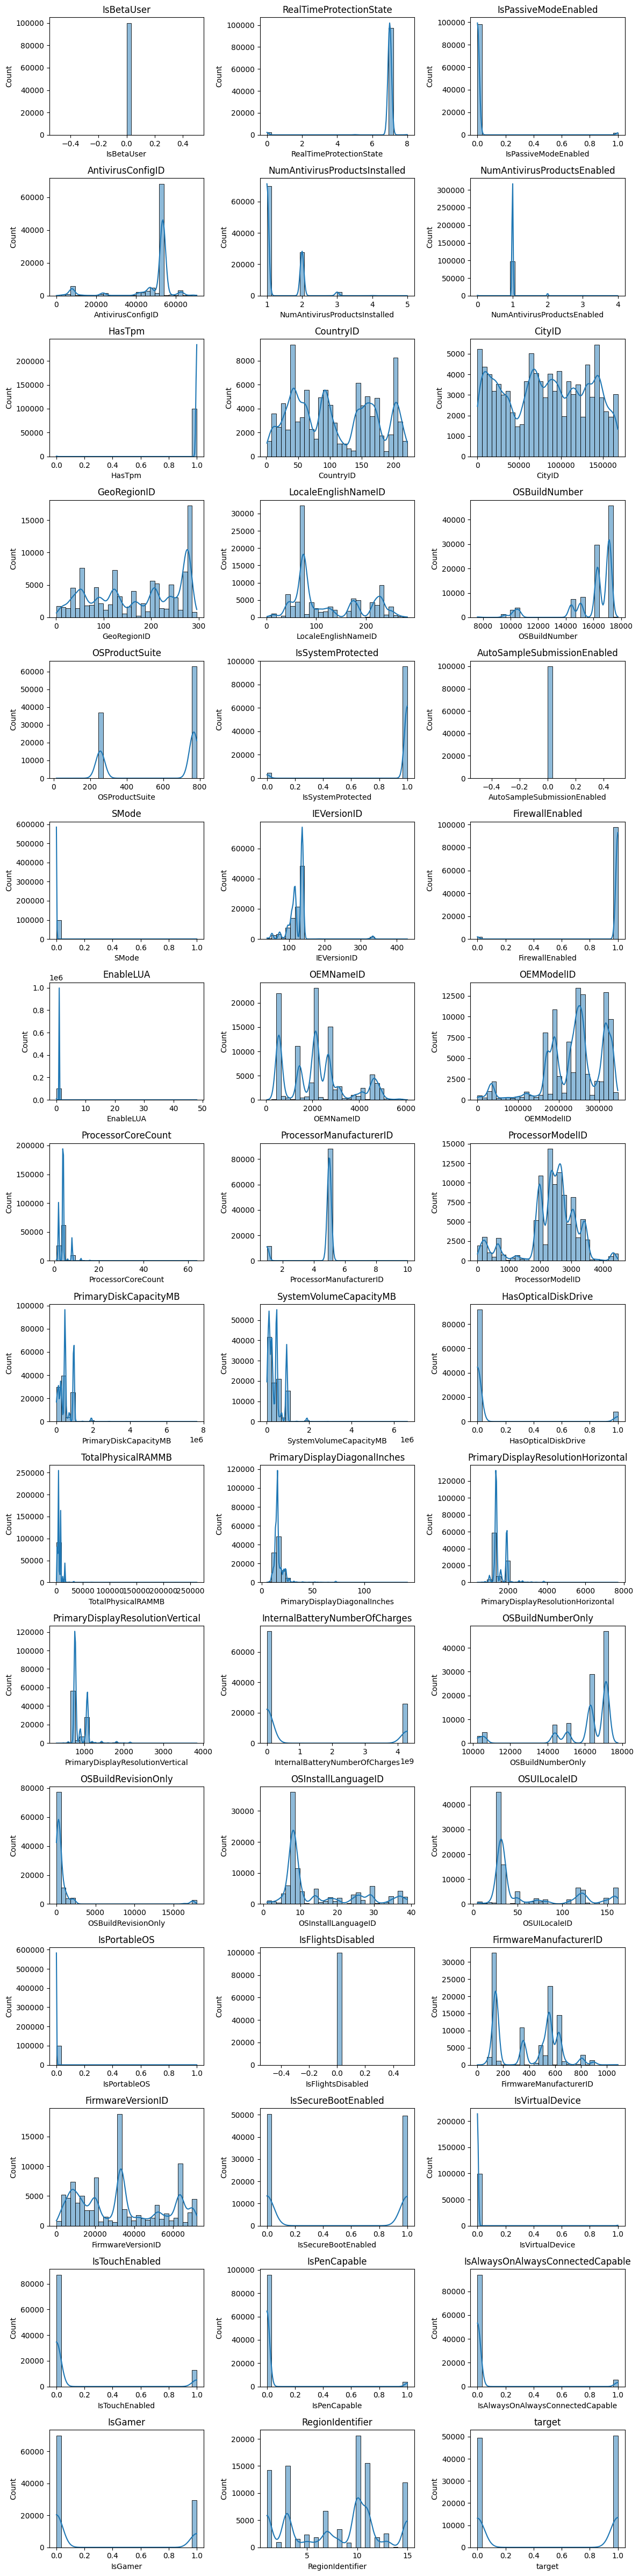

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_features = len(num_cols)
num_rows = int(np.ceil(num_features / 3))

plt.figure(figsize=(12, num_rows * 3))

for i, col in enumerate(num_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'{col}')

plt.tight_layout()
plt.show()


## 🔗 Correlation Heatmap for Numerical Features

To identify relationships between numerical features, we generate a correlation heatmap. This visual helps detect multicollinearity, redundant features, or strong positive/negative associations.

Highly correlated features can affect model performance and may require dimensionality reduction or feature selection. Additionally, it gives an early idea of which features might influence the target variable.


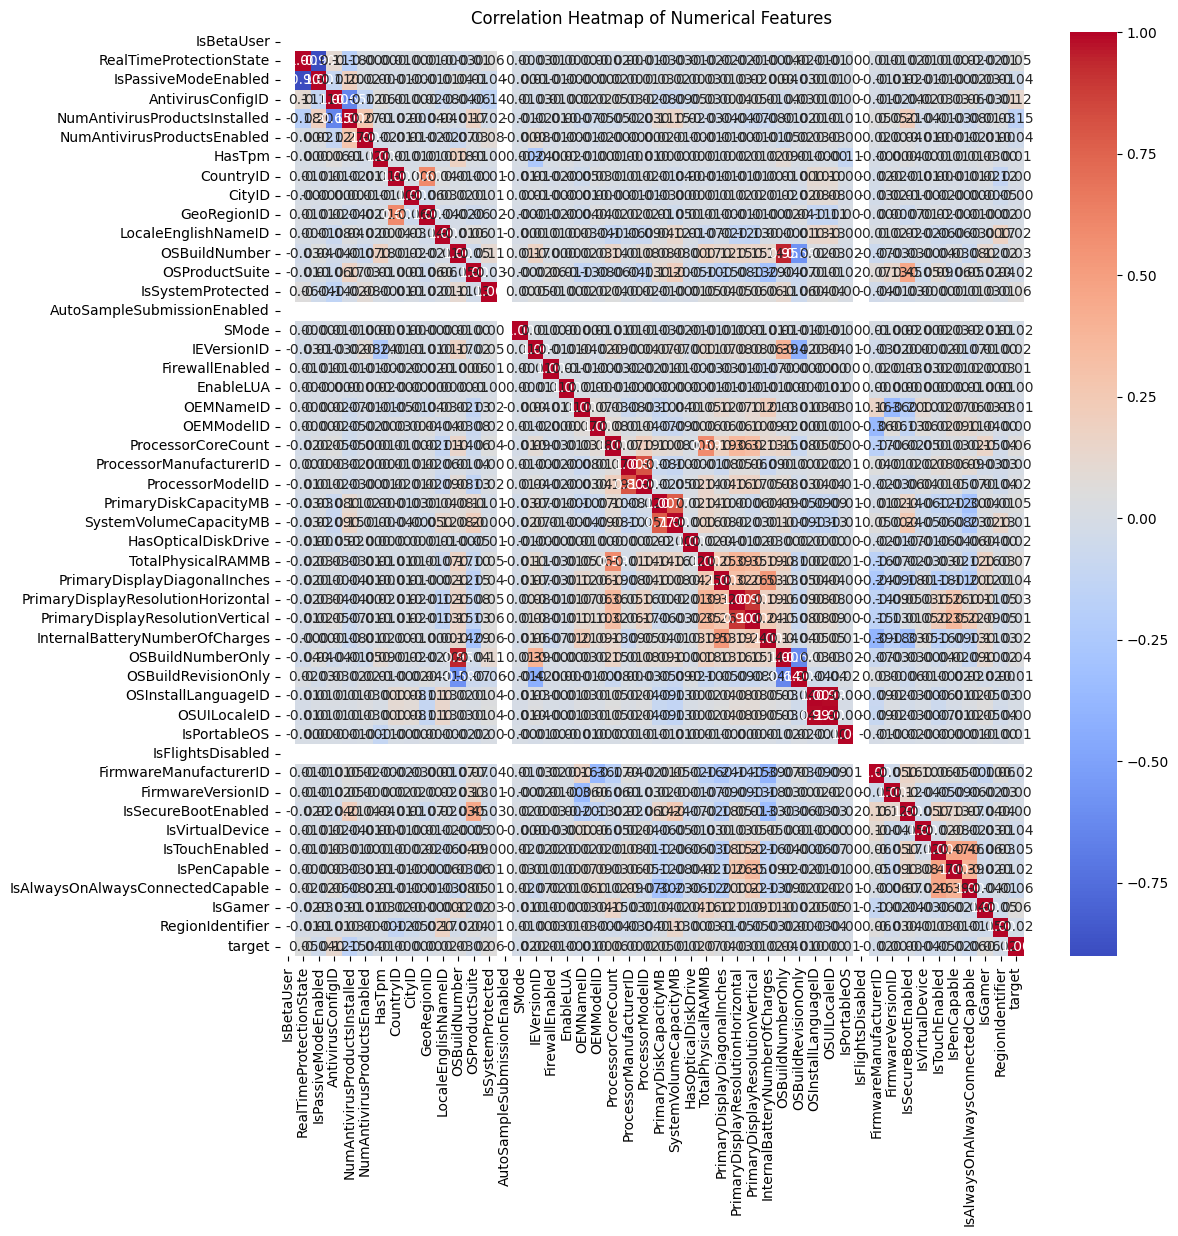

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
numerical_df = df.select_dtypes(include=['float64','int64'])

corr_matrix = numerical_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 📦 Boxplot for Outlier Detection

Boxplots are a powerful tool to visually identify outliers in numerical features. They display the distribution of data based on the median, quartiles, and highlight values that lie outside the interquartile range (IQR), which are considered potential outliers.


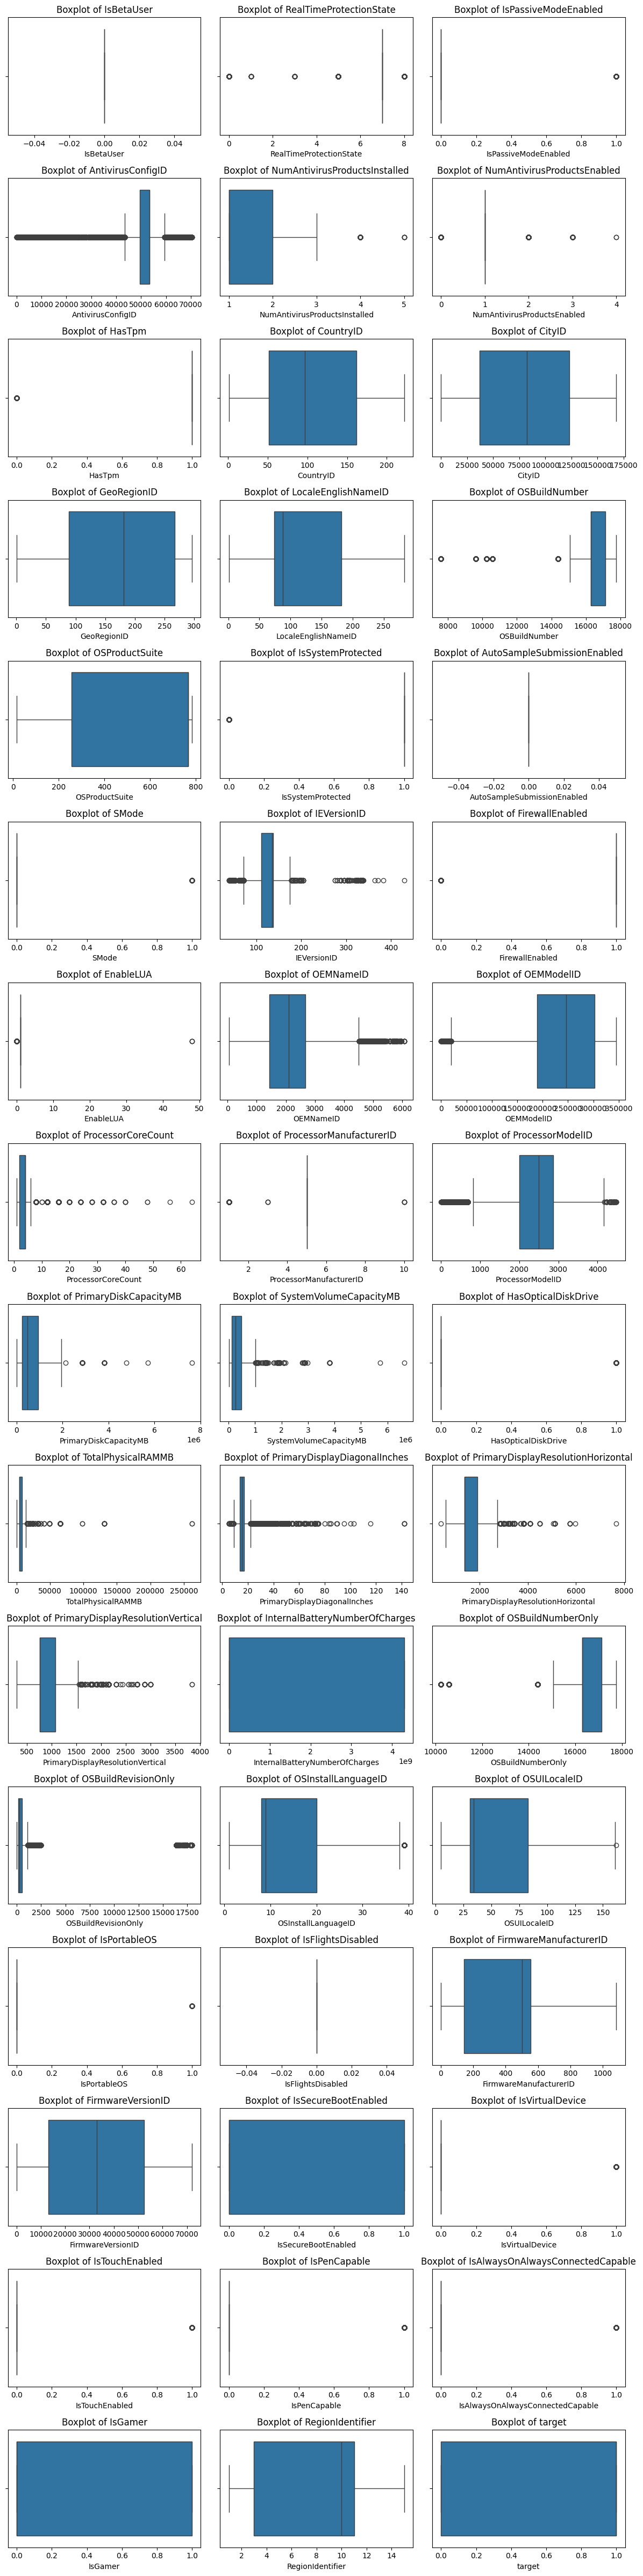

In [ ]:
num_rows=int(np.ceil(len(num_cols)/3))
plt.figure(figsize=(12, num_rows * 3))
for i, col in enumerate(num_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## 🧮 Distribution of Categorical Features (Low Cardinality)

To better understand categorical variables, we plot countplots for features with fewer than 20 unique values. These plots reveal the frequency distribution of each category and help identify:

- Dominant categories that may heavily influence the model.
- Rare categories that might need to be grouped under an "Other" label.
- Imbalanced distributions, which can affect model bias and accuracy.


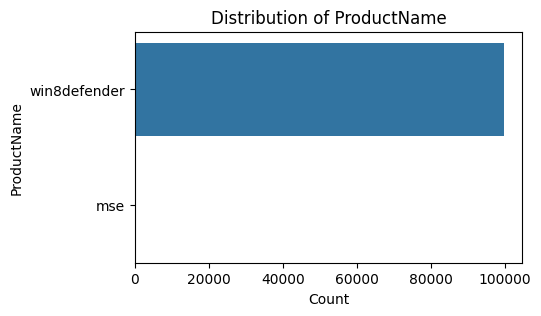

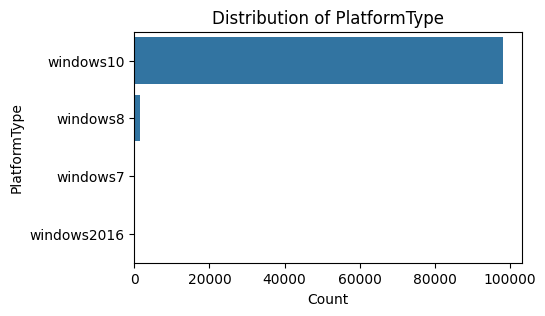

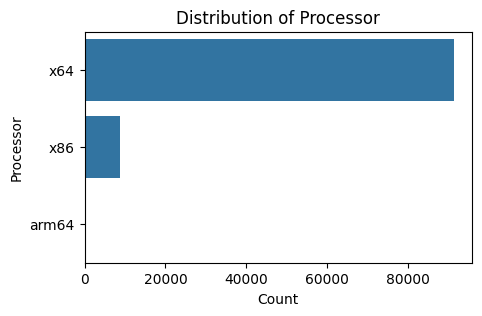

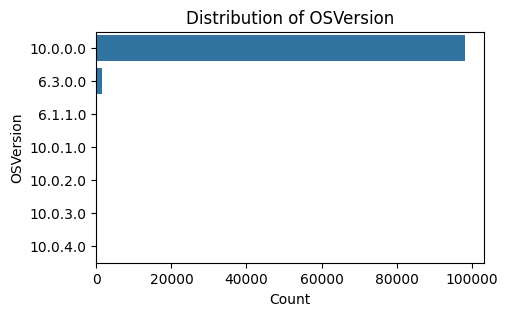

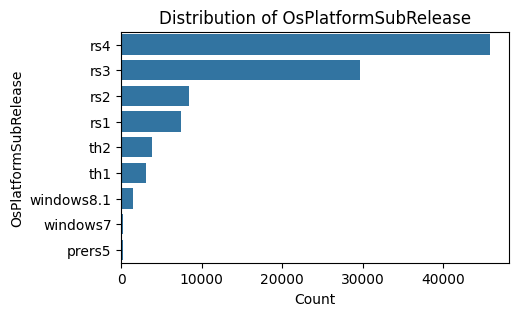

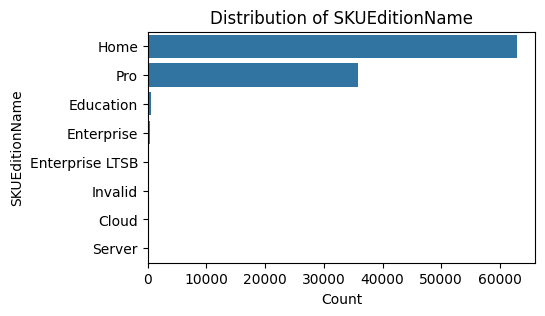

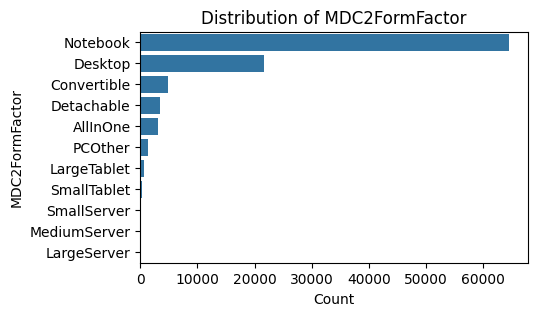

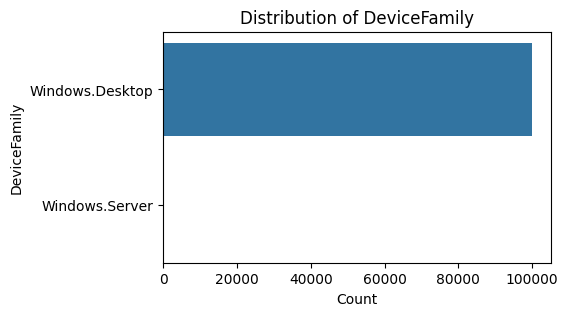

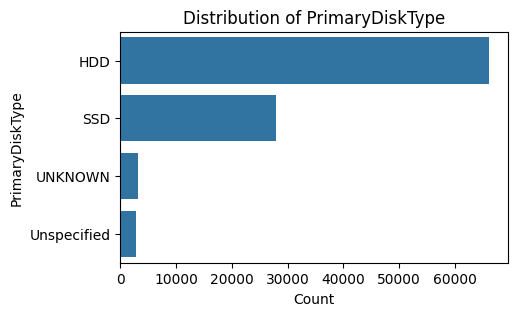

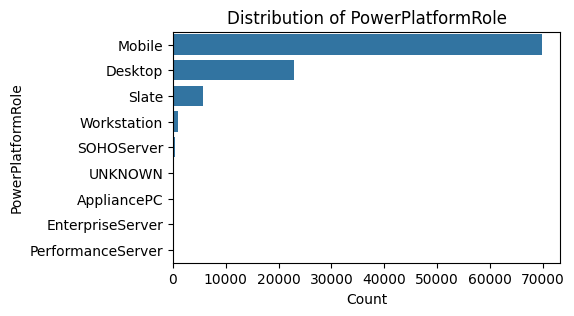

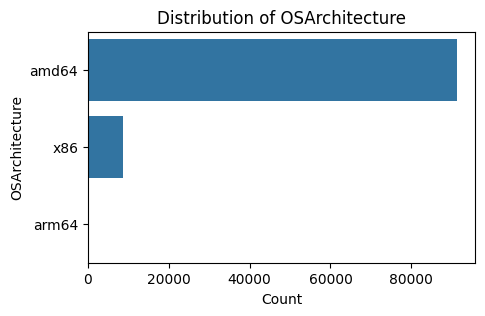

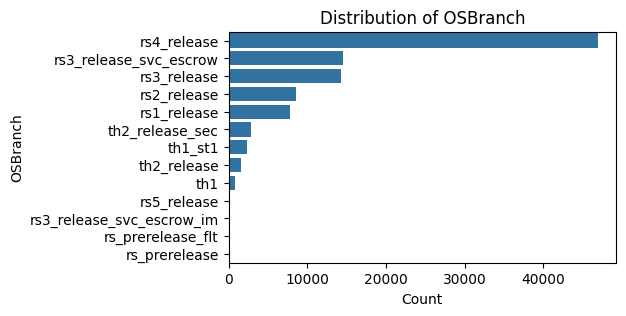

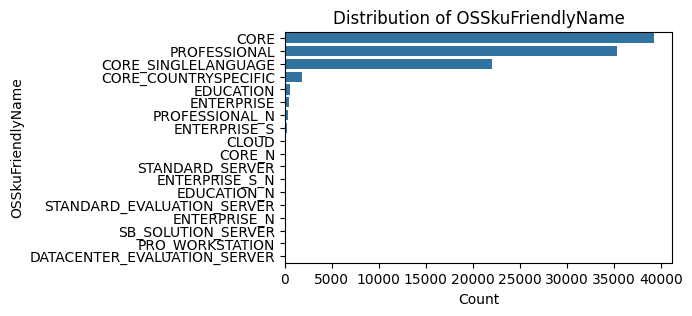

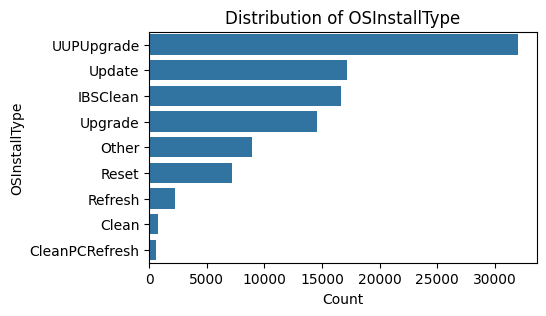

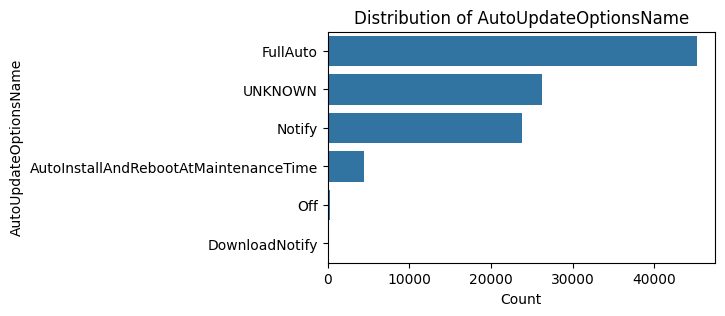

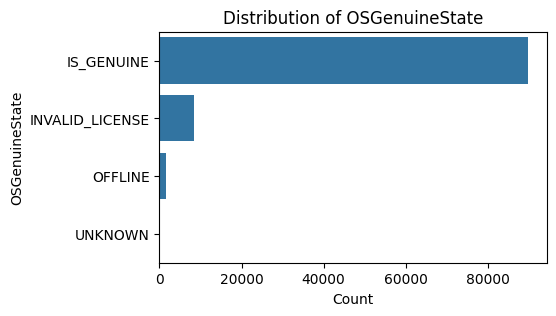

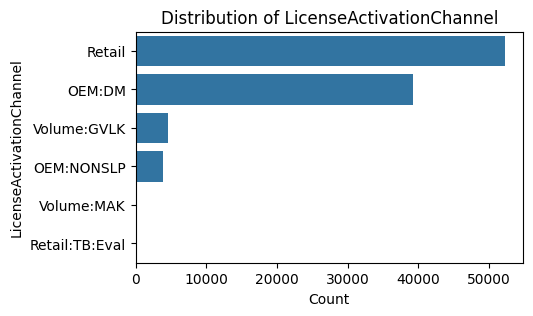

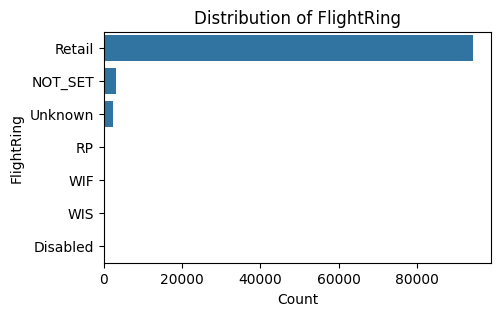

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = [col for col in df.select_dtypes(include=['object']).columns if df[col].nunique()<20]

for col in cat_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

## 🧪 Baseline Model – Dummy Classifier

Before building complex models, we establish a baseline using a `DummyClassifier`. This helps us understand how well a random or majority-class model performs, so we can compare it against real machine learning models later.

We’ll use the strategy `"most_frequent"` to always predict the majority class.


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = df.drop(columns=['target'])
y = df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)
# Initialize the DummyClassifier
dummy_clf = DummyClassifier(strategy='most_frequent').fit(X_train,y_train)

# Make predictions
y_pred = dummy_clf.predict(X_test)
print(accuracy_score(y_test,y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### 📊 Interpretation:
- The dummy classifier provides a benchmark for accuracy and precision.
- Any real ML model should outperform this baseline to be considered effective.


# **Milestone 1**

## 📝 Feature-Based Query Analysis

We perform targeted queries on the cleaned dataset (`df1`), which contains no missing values, to extract specific insights related to OS versions, system specs, and threat detection:

1. **Count of unique operating system versions**:  
   Determine how many distinct `OSVersion` values exist in the dataset.

2. **Maximum antivirus products installed**:  
   Identify the maximum value in the `NumAntivirusProductsInstalled` feature.

3. **Gamer systems with malware**:  
   Count the number of systems where `IsGamer == 1` and malware (`target == 1`) was detected.

4. **Most frequent RealTimeProtectionState in passive mode**:  
   For systems where `IsPassiveModeEnabled == 1`, find the most common value of `RealTimeProtectionState`.

5. **Systems with 1366 x 768 resolution**:  
   Count how many systems have a screen resolution of 1366 (horizontal) by 768 (vertical).

6. **Median physical RAM (MB)**:  
   Compute the 50th percentile of `TotalPhysicalRAMMB` to understand the central memory capacity of systems.


In [ ]:
df1=df.dropna()
#1 How many unique versions of the operating system are present in the dataset?
print(df1["OSVersion"].unique().shape[0])

#2 What is the maximum value of the feature “NumAntivirusProductsInstalled”?
print(df1["NumAntivirusProductsInstalled"].max())

#3 In how many systems owned by gamers was malware detected?
print(df1[(df1["IsGamer"]==1) & (df1["target"]==1)].shape[0])

#4For observations where the feature “IsPassiveModeEnabled” equals “1,” what is the most frequent value of the feature “RealTimeProtectionState”?
print(df1[df1["IsPassiveModeEnabled"]==1]["RealTimeProtectionState"].value_counts().idxmax())

#5 How many systems have a screen resolution of 1366 x 768?
print(df1[(df1["PrimaryDisplayResolutionHorizontal"]==1366) & (df1["PrimaryDisplayResolutionVertical"]==768)].shape[0])

#6 What is the 50th percentile value of “TotalPhysicalRAMMB”?
print(df1["TotalPhysicalRAMMB"].median())

7
5.0
15991
0.0
49926
4096.0


# **MILESTONE 2**

## Data Preprocessing & Modeling Steps

1. **Redundant Columns:**  
   Identify columns with only one unique value.

2. **Correlation Analysis:**  
   Use Cramér's V to find pairs of categorical columns with the highest positive association.

3. **Categorical Encoding:**  
   Select object columns; for those with ≤10 unique values, apply OneHotEncoder. Output the new column count.

4. **Numerical Scaling:**  
   Select numeric columns, scale with MinMaxScaler, and compute the sum of all scaled values.

5. **Imputation, Encoding, Modeling:**  
   Impute missing values, ordinal encode categoricals, split data, train an SGDClassifier, and print accuracy.


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

# Assuming df is already defined
df1 = df.copy()
X = df1.drop("target", axis=1)
y = df["target"]

# 1. Identify the redundant columns in the training dataset based on the values taken.
redundent_cols = [col for col in df1.columns if df1[col].nunique() == 1]
print(redundent_cols)

# 2. Determine the columns among the given set which have the highest positive correlation
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

print(cramers_v(df1['DateAS'], df1['SignatureVersion']))
print(cramers_v(df1['OSBuildLab'], df1['NumericOSVersion']))
print(cramers_v(df1['OSEdition'], df1['OSSkuFriendlyName']))
print(cramers_v(df1['OSProductSuite'], df1['OSSkuFriendlyName']))

# 3. Create a new dataframe called cat_df which contains only the columns of datatype 'object'.
# In cat_df, for all the columns which take less than or equal to 10 unique values, use OneHotEncoder.
cat_df = df.select_dtypes(include=["object"])
req_cols = [col for col in cat_df.columns if cat_df[col].nunique() <= 10]

# Apply OneHotEncoder
encoder = OneHotEncoder(sparse=False, drop='first', handle_unknown='ignore')
encoded_data = encoder.fit_transform(cat_df[req_cols])

# Create DataFrame for the encoded columns
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(req_cols))

# Drop the original columns and concatenate the encoded columns
cat_df = cat_df.drop(columns=req_cols)
cat_df = pd.concat([cat_df, encoded_df], axis=1)
print(cat_df.shape[1])

# 4. Create a new dataframe called num_df which contains only the columns of datatype 'int64' and 'float64'.
# Use MinMaxScaler() on num_df.
num_df = df.select_dtypes(include=['int64', 'float64'])

scaler = MinMaxScaler()
num_df_scaled = pd.DataFrame(scaler.fit_transform(num_df), columns=num_df.columns)

# Print the sum of all the values in num_df_scaled
print(num_df_scaled.sum().sum())  # Required Sum

# 5. Imputing missing values
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

categorical_cols = X_imputed.select_dtypes(include=['object']).columns

# Apply OrdinalEncoder on categorical columns
encoder = OrdinalEncoder()
X_imputed[categorical_cols] = encoder.fit_transform(X_imputed[categorical_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# Train an SGDClassifier
clf = SGDClassifier(random_state=42)
clf.fit(X_train, y_train)

# Accuracy
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))


# **MILESTONE 3**

## Data Preprocessing, Decision Tree Modeling and AdaBoostClassification

- **Preprocessing:**  
  - Label encode categorical features.
  - Impute missing values (categorical: most frequent, numerical: mean).
  - Scale numerical features with StandardScaler.
  - Combine transformations using ColumnTransformer.

- **Model Training:**  
  - Split data into train and test sets.
  - Fit a DecisionTreeClassifier.
  - Perform hyperparameter tuning (max_depth, min_samples_split, min_samples_leaf) using GridSearchCV with 3-fold cross-validation and accuracy scoring.

- **Results:**  
  - Print best hyperparameters and test accuracy.


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Copy the dataset
df1 = df.copy()

# Define features and target
X = df1.drop(columns=['target'])
y = df1['target']

# Select numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

cat_pipe=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
])

num_pipe=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

transform=ColumnTransformer(transformers=[
    ('cat',cat_pipe,cat_cols),
    ('num',num_pipe,num_cols)
],remainder='passthrough')

transformed_X=transform.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2, random_state=42)

# Print Shapes
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Fit a Decision tree model (random state 42) on the training set and perform hyper parameter tuning using grid search with 3 folds and use scoring as accuracy

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_model = DecisionTreeClassifier(random_state=42)

# Hyperparameters for tuning
param_grid = {
    'max_depth': [20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Perform Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_params=grid_search.best_params_
#1
print("Best max_depth:", best_params['max_depth'])
#2
print("Best min sample split",best_params['min_samples_split'])
#3
print("Best min sample leaf",best_params['min_samples_leaf'])
#4
best_dt_model = grid_search.best_estimator_
y_pred = best_dt_model.predict(X_test)

print(accuracy_score(y_test, y_pred))


Train shape: (80000, 75)
Test shape: (20000, 75)
Best max_depth: 20
Best min sample split 2
Best min sample leaf 1
0.56485


In [ ]:
#4 Fit an AdaBoostClassifier model (random state 42) on the training set and perform hyper parameter tuning using grid search with 3 folds and use scoring as accuracy
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

adaboost=AdaBoostClassifier(random_state=42)

params_grid={
    'n_estimators': [10, 20, 30],
    'learning_rate': [5, 10],
    'algorithm': ['SAMME']
}

grid_search=GridSearchCV(
    estimator=adaboost,
    param_grid=params_grid,
    cv=2,
    scoring="accuracy",
    n_jobs=-1)
grid_search.fit(X_train,y_train)

best_params=grid_search.best_params_

#5
print(" Best estimator ",best_params['n_estimators'])
#6
print(" Best learning rate ",best_params['learning_rate'])
#7
best_ada_model=grid_search.best_estimator_
y_pred=best_ada_model.predict(X_test)
print("Accuracy ",accuracy_score(y_test,y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


 Best estimator  10
 Best learning rate  5
Accuracy  0.42665


# **MILESTONE 4**

## Preprocessing, PCA, and Feature Selection

- **Preprocessing:**  
  - Drop missing values.
  - Ordinal encode categorical columns.
  - Standard scale all features.

- **PCA (Principal Component Analysis):**
  1. Find the minimum number of components to explain at least 70% variance.
  2. Reconstruct data using these components and calculate mean squared error (MSE).
  3. Calculate total variance explained by the first 40 principal components.

- **Feature Selection:**
  4. Use SelectKBest (ANOVA F-value) to select the 15 most important features.
  5. Print the highest feature score among all features.


In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#preprocessing
df1=df.dropna()
X = df1.drop(columns=['target'])
y = df1['target']

cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# preprocessing pipeline
#   - Use OrdinalEncoder for categorical columns.
#   - Use StandardScaler for all columns.
preprocessor = Pipeline(steps=[
    ('ordinal_encoder', ColumnTransformer(
        transformers=[
        ('cat', OrdinalEncoder(), cat_cols)
        ],
        remainder='passthrough'
    )),
    ('scaler', StandardScaler())
])
X_processed = preprocessor.fit_transform(X)

**PCA**

In [ ]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import mean_squared_error

pca=PCA()
X_pca=pca.fit_transform(X_processed)

explained_variance = np.cumsum(pca.explained_variance_ratio_)
#1
n_comp=np.argmax(explained_variance >= 0.70) + 1
print(n_comp)

#2
pca_2 = PCA(n_components=n_comp)
X_pca_2 = pca_2.fit_transform(X_processed)

# Reconstruct the data
X_reconstructed = pca_2.inverse_transform(X_pca_2)

mse = mean_squared_error(X_processed, X_reconstructed)
print(mse)

#3
pca_40 = PCA(n_components=40)
X_pca_40 = pca_40.fit_transform(X_processed)

variance_explained_40 = np.sum(pca_40.explained_variance_ratio_)
print(variance_explained_40)

22
0.2804402090812571
0.9179224293715358


In [ ]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest,f_classif

#4
selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X_processed, y)

X_processed_df = pd.DataFrame(X_processed, columns=X.columns)

selected_mask = selector.get_support()
selected_features = X_processed_df.columns[selected_mask]
print("Selected features:", selected_features.tolist())

#5
best_feature_score = np.nanmax(selector.scores_)
print("Best feature score:", best_feature_score)

Selected features: ['EngineVersion', 'RealTimeProtectionState', 'LocaleEnglishNameID', 'Processor', 'IEVersionID', 'EnableLUA', 'DeviceFamily', 'OEMNameID', 'TotalPhysicalRAMMB', 'OSArchitecture', 'OSBuildRevisionOnly', 'OSInstallType', 'IsAlwaysOnAlwaysConnectedCapable', 'RegionIdentifier', 'DateAS']
Best feature score: 2286.2347657429214


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [12 28 42 65] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


# **Preprocessing**

This code first removes columns with only one unique value, then detects categorical and numerical columns in the dataset. For preprocessing, numerical features are imputed using the median and scaled with StandardScaler, while categorical features are imputed with the most frequent value and encoded using OrdinalEncoder (handling unknown values). These transformations are combined using a ColumnTransformer, and the resulting preprocessed feature matrix is produced and its shape displayed.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

def detectColumnTypes(X):
    X = X.loc[:, X.nunique() > 1]
    cat_cols=X.select_dtypes(include=['object']).columns
    num_cols=X.select_dtypes(include=['float64','int64']).columns
    return  X,cat_cols, num_cols

#Preprocessing for numerical features
num_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
cat_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

X_cleaned, cat_cols, num_cols = detectColumnTypes(X)

# Column transformer pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_preprocessor, num_cols),
        ('cat', cat_preprocessor, cat_cols)
    ]
)

# Apply preprocessing to the dataset
X_preprocessed = preprocessor.fit_transform(X_cleaned, y)
X_preprocessed.shape

(100000, 72)

# **Logistic Regression**

This code applies logistic regression, a supervised machine learning algorithm commonly used for binary classification tasks by predicting the probability that an instance belongs to a particular class. The model is trained on preprocessed data, with hyperparameters such as regularization strength (C), penalty type, and solver tuned using GridSearchCV and cross-validation to optimize accuracy. After selecting the best model, its performance is evaluated on a held-out test set using metrics like accuracy, classification report, and confusion matrix. Finally, the model is used to generate predictions on an external test dataset, and the results are saved for submission. Logistic regression leverages the logistic (sigmoid) function to map predictions to probabilities between 0 and 1, making it ideal for classification problems with discrete outcomes

Hyperparamter Tuning

In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3, random_state=42)

# Parameter Grid
param_grid = {
    'penalty': ['l2'],
    'C': [0.001, 0.01, 0.1, 1],
    'solver': ['newton-cg']
}

# Logistic Regression Model
logreg = LogisticRegression()

# RandomizedSearchCV
grid_search = GridSearchCV(logreg, param_grid=param_grid,cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
Best score: 0.5964713361631451


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3, random_state=42)
# Initialize the Logistic Regression model
lr_model = grid_search.best_estimator_

# Fit the model on the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
# Load the test data from the CSV file
X_testf = pd.read_csv('System-Threat-Forecaster/test.csv')

# Apply the same preprocessing to the test data
X_testf = preprocessor.transform(X_testf)

# Make predictions on the external test data
y_testf = lr_model.predict(X_testf)

# Create the submission DataFrame
submission = pd.DataFrame({"id": range(0, X_testf.shape[0]), "target": y_testf})

# Save the submission to a CSV file
submission.to_csv('submission.csv', index=False)

# Print the shape of the submission
print(submission.shape)

Accuracy: 59.81%
              precision    recall  f1-score   support

           0       0.62      0.51      0.56     14920
           1       0.59      0.68      0.63     15080

    accuracy                           0.60     30000
   macro avg       0.60      0.60      0.59     30000
weighted avg       0.60      0.60      0.60     30000

[[ 7626  7294]
 [ 4764 10316]]
(10000, 2)


### Logistic Regression Results: Conclusions

- The logistic regression model achieved an accuracy of **59.81%** on the test set, indicating moderate predictive performance.
- The model demonstrates higher recall for class 1 (0.68) compared to class 0 (0.51), suggesting it is better at identifying positive cases.
- Precision and recall are relatively balanced, with f1-scores of 0.56 for class 0 and 0.63 for class 1, but there is still room for improvement, especially for class 0.
- The confusion matrix shows a notable number of misclassifications, particularly for class 0, which may be significant depending on the application.
- To enhance performance, further steps such as advanced modeling techniques, feature engineering, or addressing potential class imbalance could be considered.

# DecisionTreeClassifier

This code implements a Decision Tree classifier, a versatile machine learning algorithm used for both classification and regression tasks. The dataset is split into training and testing sets, and hyperparameter tuning is performed using RandomizedSearchCV to efficiently search across a range of values for parameters such as tree depth, minimum samples per split and leaf, feature selection strategy, and split criterion. The best model is selected based on cross-validated accuracy, then evaluated on the test set with metrics including accuracy, classification report, and confusion matrix. Decision Trees work by recursively splitting the data based on feature values, creating a model that is easy to interpret and capable of capturing complex relationships in the data.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3, random_state=16)

# Define hyperparameter space
param_dist = {
    'max_depth': np.arange(5, 30, 5),
    'min_samples_split': np.arange(2, 50, 5),
    'min_samples_leaf': np.arange(1, 20, 2),
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Use RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    dt_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Perform hyperparameter search
random_search.fit(X_train, y_train)

# Print best parameters
print("Best parameters:", random_search.best_params_)
print("Best accuracy:", random_search.best_score_)

# Train Decision Tree with best parameters
best_dt = random_search.best_estimator_
y_pred = best_dt.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Final Test Accuracy: {accuracy * 100:.2f}%')
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Best parameters: {'min_samples_split': np.int64(2), 'min_samples_leaf': np.int64(7), 'max_features': 'sqrt', 'max_depth': np.int64(10), 'criterion': 'gini'}
Best accuracy: 0.5883142384040695
Final Test Accuracy: 59.21%
              precision    recall  f1-score   support

           0       0.61      0.48      0.54     14787
           1       0.58      0.70      0.64     15213

    accuracy                           0.59     30000
   macro avg       0.60      0.59      0.59     30000
weighted avg       0.60      0.59      0.59     30000

[[ 7080  7707]
 [ 4531 10682]]


### Decision Tree Classifier Results: Conclusions

- The Decision Tree model achieved a best cross-validated accuracy of **58.83%** and a final test accuracy of **59.21%**.
- The optimal hyperparameters found were:  
  `min_samples_split = 2`, `min_samples_leaf = 7`, `max_features = 'sqrt'`, `max_depth = 10`, and `criterion = 'gini'`.
- The model performs better at identifying class 1 (recall: 0.70) than class 0 (recall: 0.48), indicating a tendency to favor positive cases.
- F1-scores are 0.54 for class 0 and 0.64 for class 1, showing moderate but unbalanced performance between classes.
- The confusion matrix reveals a substantial number of misclassifications for class 0, with 7,707 false positives, suggesting the model may benefit from further tuning or addressing class imbalance.
- Overall, while the Decision Tree provides interpretable results, there is room for improvement in both accuracy and class balance, potentially through ensemble methods or additional feature engineering.

# Random Forest Classifier
This code uses a Random Forest classifier, an ensemble learning method that builds multiple decision trees and combines their predictions for improved accuracy and robustness. After splitting the preprocessed data into training and test sets, a Random Forest model is trained and used for feature selection, retaining only the most important features based on the model's learned importances. The model is then retrained using these selected features, and its performance is evaluated on the test set using accuracy, classification report, and confusion matrix. Random Forests are effective for handling high-dimensional data and reducing overfitting, making them a popular choice for classification problems.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3, random_state=16)

#Random Forest model
rf_model = RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train,y_train)

# Feature Selection using Random Forest
selector = SelectFromModel(rf_model, threshold="median",prefit=True)

# Apply Feature Selection to Training and Testing Sets
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Train the Model with Selected Features
rf_model.fit(X_train_selected, y_train)

# Predictions
y_pred = rf_model.predict(X_test_selected)

# Model Performance
accuracy = accuracy_score(y_test, y_pred)
print(f'✅ Random Forest Accuracy: {accuracy * 100:.2f}%')
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


✅ Random Forest Accuracy: 61.71%
              precision    recall  f1-score   support

           0       0.63      0.56      0.59     14787
           1       0.61      0.68      0.64     15213

    accuracy                           0.62     30000
   macro avg       0.62      0.62      0.62     30000
weighted avg       0.62      0.62      0.62     30000

[[ 8223  6564]
 [ 4924 10289]]


### Random Forest Classifier Results: Conclusions

- The Random Forest model achieved an accuracy of **61.71%** on the test set, outperforming both logistic regression and decision tree models in this workflow.
- The model shows balanced performance, with precision and recall scores of 0.63 and 0.56 for class 0, and 0.61 and 0.68 for class 1, respectively.
- The f1-scores are 0.59 for class 0 and 0.64 for class 1, indicating better performance in identifying class 1 samples.
- The confusion matrix reveals that the model correctly classified 8,223 instances of class 0 and 10,289 instances of class 1, but still misclassified a notable number of samples, especially for class 0.
- Overall, the Random Forest classifier demonstrates improved accuracy and more balanced class-wise performance compared to previous models, but further enhancements such as hyperparameter tuning, advanced feature engineering, or addressing class imbalance could yield even better results.


# **XGBoost**

This code implements an XGBoost classifier, a powerful gradient boosting algorithm widely used for structured data tasks. The model’s hyperparameters are optimized using RandomizedSearchCV with cross-validation to maximize accuracy. After training the best model, feature selection is performed based on feature importances, retaining only the most relevant features. The XGBoost model is then retrained on these selected features, and its performance is evaluated on the test set using accuracy, classification report, and confusion matrix. The same preprocessing and feature selection steps are applied to an external test dataset, and predictions are generated for submission. XGBoost is known for its efficiency, scalability, and superior performance on a variety of classification problems.

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=16)

param_dist = {
    'n_estimators': [50, 100, 150, 200, 250],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb_model = XGBClassifier(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(xgb_model, param_dist, cv=3, scoring='accuracy',n_jobs=-1)
random_search.fit(X_train, y_train)

best_params=random_search.best_params_
print(f'best parameters are {best_params}')

# Train XGBoost Model Before Feature Selection
xgb_model = XGBClassifier(**best_params, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
# Feature Selection using XGBoost
selector = SelectFromModel(xgb_model, threshold="median", prefit=True)

# Apply Feature Selection to Training and Testing Sets
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Retrain the XGBoost Model with Selected Features
xgb_selected_model = XGBClassifier(**best_params, random_state=42, n_jobs=-1)
xgb_selected_model.fit(X_train_selected, y_train)

# Predictions
y_pred = xgb_selected_model.predict(X_test_selected)

# Model Performance
accuracy = accuracy_score(y_test, y_pred)
print(f'✅ XGBoost Accuracy: {accuracy * 100:.2f}%')
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


best parameters are {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
✅ XGBoost Accuracy: 63.00%
              precision    recall  f1-score   support

           0       0.64      0.58      0.61      9852
           1       0.62      0.68      0.65     10148

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000

[[5697 4155]
 [3246 6902]]


### XGBoost Classifier Results: Conclusions

- The XGBoost model achieved an accuracy of **63.00%** on the test set, representing the best performance among the models evaluated so far.
- The best hyperparameters found were: `n_estimators = 100`, `max_depth = 6`, and `learning_rate = 0.1`.
- The model demonstrates balanced performance, with precision and recall scores of 0.64 and 0.58 for class 0, and 0.62 and 0.68 for class 1, respectively.
- F1-scores are 0.61 for class 0 and 0.65 for class 1, indicating strong predictive ability for both classes, with a slight edge in identifying class 1 samples.
- The confusion matrix shows that the model correctly classified 5,697 instances of class 0 and 6,902 instances of class 1, but there are still a notable number of misclassifications, especially for class 0.
- Overall, XGBoost provides the highest accuracy and the most balanced class-wise performance so far, but further improvements could be achieved through additional feature engineering, advanced tuning, or ensemble approaches.


# **LightGBM**

This code applies a LightGBM classifier, a fast and efficient gradient boosting algorithm, to the preprocessed dataset for classification. The model is first trained on the training data, and feature selection is performed using the model’s feature importances, retaining only the most relevant features. The classifier is then retrained on the selected features, and its performance is evaluated on the test set using accuracy, classification report, and confusion matrix. The same preprocessing and feature selection steps are applied to an external test dataset, and predictions are generated for submission. LightGBM is known for its speed and effectiveness, especially with large and high-dimensional datasets.

In [ ]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=16)

# Initialize and train LightGBM model with default parameters
lgbm_model = LGBMClassifier(random_state=42, n_jobs=-1)
lgbm_model.fit(X_train, y_train)

# Feature selection using LightGBM
selector = SelectFromModel(lgbm_model, threshold="median", prefit=True)

# Apply feature selection
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Retrain LightGBM on selected features
lgbm_selected_model = LGBMClassifier(random_state=42, n_jobs=-1)
lgbm_selected_model.fit(X_train_selected, y_train)

# Predictions and evaluation
y_pred = lgbm_selected_model.predict(X_test_selected)
accuracy = accuracy_score(y_test, y_pred)
print(f'✅ LightGBM Accuracy: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 40377, number of negative: 39623
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.136127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5044
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.504713 -> initscore=0.018851
[LightGBM] [Info] Start training from score 0.018851


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 40377, number of negative: 39623
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010811 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4690
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.504713 -> initscore=0.018851
[LightGBM] [Info] Start training from score 0.018851
✅ LightGBM Accuracy: 62.70%
              precision    recall  f1-score   support

           0       0.63      0.58      0.61      9852
           1       0.62      0.67      0.65     10148

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000

[[5725 4127]
 [3332 6816]]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### LightGBM Classifier Results: Conclusions

- The LightGBM model achieved an accuracy of **62.70%** on the test set, closely matching the performance of XGBoost.
- The model displays balanced precision and recall across both classes: for class 0, precision is 0.63 and recall is 0.58; for class 1, precision is 0.62 and recall is 0.67.
- F1-scores are 0.61 for class 0 and 0.65 for class 1, indicating consistent and reliable performance for both classes.
- The confusion matrix shows that the model correctly classified 5,725 instances of class 0 and 6,816 instances of class 1, with a moderate number of misclassifications.
- Overall, LightGBM demonstrates strong and balanced predictive ability, making it a competitive choice for this classification task. Further improvements could be explored through additional feature engineering or model ensembling.


# Conclusion

In this notebook, we explored and compared several machine learning models-including Logistic Regression, Decision Tree, Random Forest, XGBoost, and LightGBM-for the classification task. Through systematic preprocessing, feature selection, and model evaluation, we observed incremental improvements in predictive performance.

- **Baseline models** like Logistic Regression and Decision Tree provided moderate accuracy but struggled with class imbalance and misclassification, particularly for class 0.
- **Ensemble methods** such as Random Forest, XGBoost, and LightGBM showed notable improvements in both overall accuracy and class-wise performance, with XGBoost achieving the highest test accuracy of **63.00%**.
- Both XGBoost and LightGBM demonstrated balanced precision, recall, and f1-scores across classes, making them robust choices for this task.

Despite these gains, there remains room for further enhancement. Future work could focus on advanced feature engineering, deeper hyperparameter tuning, handling class imbalance, or leveraging model ensembling techniques to push performance even higher.

Overall, this workflow highlights the importance of iterative experimentation and evaluation in building effective machine learning solutions.
